**1. Import Libraries**

Load essential libraries for data manipulation, visualization, time series analysis, and machine learning.

In [1]:
import warnings 
warnings.filterwarnings("ignore") 
import os 
import numpy as np 
import pandas as pd 
import seaborn as sns 
import xgboost as xgb 
import plotly.express as px
import matplotlib.pyplot as plt 
from sklearn.model_selection import KFold 
from xgboost import plot_importance, plot_tree 
from sklearn.model_selection import train_test_split 
from statsmodels.tsa.seasonal import seasonal_decompose 
from sklearn.metrics import mean_absolute_percentage_error 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [2]:
def PlotDecomposition(result):
 plt.figure(figsize=(22,18))
 plt.subplot(4,1,1)
 plt.plot(result.observed,label='Observed',lw=1)
 plt.legend(loc='upper left')
 plt.subplot(4,1,2)
 plt.plot(result.trend,label='Trend',lw=1)
 plt.legend(loc='upper left')
 plt.subplot(4, 1, 3)
 plt.plot(result.seasonal, label='Seasonality',lw=1)
 plt.legend(loc='upper left')
 plt.subplot(4, 1, 4)
 plt.plot(result.resid, label='Residuals',lw=1)
 plt.legend(loc='upper left')
 plt.show()

In [3]:
def CalculateError(pred,sales):
     percentual_errors = []
     for A_i, B_i in zip(sales, pred):
         percentual_error = abs((A_i- B_i) / B_i)
         percentual_errors.append(percentual_error)
     return sum(percentual_errors) / len(percentual_errors)

In [4]:
def PlotPredictions(plots,title):
     plt.figure(figsize=(18, 8))
     for plot in plots:
         plt.plot(plot[0], plot[1], label=plot[2], linestyle=plot[3],
color=plot[4],lw=1)
     plt.xlabel('Date')
     plt.ylabel("Trips")
     plt.title(title)
     plt.legend()
     plt.xticks(rotation=30, ha='right')
     plt.show()

In [5]:
def create_lagged_features(data, window_size):
     X, y = [], []
     for i in range(len(data)- window_size):
         X.append(data[i:i+window_size])
         y.append(data[i+window_size])
     return np.array(X), np.array(y)

**2. Load Dataset**

All monthly Uber trip files from April–September 2014 are merged into a single DataFrame.

In [6]:
df = pd.read_csv(r"C:\Users\sunil\Downloads\uber-raw-data-janjune-15.csv")

In [7]:
# Renaming the Date/Time Column
df = df.rename(columns={'Pickup_date': 'Date'})

# Converting the Date_time type into Datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')


# Adding useful columns
df['Month'] = df['Date'].dt.month_name()
df['Weekday'] = df['Date'].dt.day_name() 
df['Day'] = df['Date'].dt.day
df['Hour'] = df['Date'].dt.hour
df['Minute'] = df['Date'].dt.minute

In [8]:
df

,Dispatching_base_num,Date,Affiliated_base_num,locationID,Month,Weekday,Day,Hour,Minute
832778,B02764,2015-01-01 00:00:05,B02764,255,January,Thursday,1,0,0
90608,B02598,2015-01-01 00:00:05,B02598,144,January,Thursday,1,0,0
9371715,B02682,2015-01-01 00:00:08,B02682,113,January,Thursday,1,0,0
9368311,B02682,2015-01-01 00:00:11,B02617,234,January,Thursday,1,0,0
1084752,B02764,2015-01-01 00:00:13,B02764,232,January,Thursday,1,0,0
...,...,...,...,...,...,...,...,...,...
8493453,B02764,2015-06-30 23:59:00,B02764,246,June,Tuesday,30,23,59
8493454,B02764,2015-06-30 23:59:00,B00628,90,June,Tuesday,30,23,59
8493455,B02764,2015-06-30 23:59:00,B02764,148,June,Tuesday,30,23,59
8493457,B02764,2015-06-30 23:59:00,B02765,231,June,Tuesday,30,23,59


In [9]:
df.columns

Index(['Dispatching_base_num', 'Date', 'Affiliated_base_num', 'locationID',
       'Month', 'Weekday', 'Day', 'Hour', 'Minute'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14270479 entries, 832778 to 7721870
Data columns (total 9 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Dispatching_base_num  object        
 1   Date                  datetime64[ns]
 2   Affiliated_base_num   object        
 3   locationID            int64         
 4   Month                 object        
 5   Weekday               object        
 6   Day                   int32         
 7   Hour                  int32         
 8   Minute                int32         
dtypes: datetime64[ns](1), int32(3), int64(1), object(4)
memory usage: 925.4+ MB


In [11]:
df.describe(include='all')

,Dispatching_base_num,Date,Affiliated_base_num,locationID,Month,Weekday,Day,Hour,Minute
count,14270479,14270479,14108284,1.427048e+07,14270479,14270479,1.427048e+07,1.427048e+07,1.427048e+07
unique,8,NaN,284,NaN,6,7,NaN,NaN,NaN
top,B02764,NaN,B02764,NaN,June,Saturday,NaN,NaN,NaN
freq,5753653,NaN,4352321,NaN,2816895,2414563,NaN,NaN,NaN
mean,NaN,2015-04-07 15:04:13.657453568,NaN,1.520574e+02,NaN,NaN,1.590227e+01,1.409316e+01,2.940928e+01
min,NaN,2015-01-01 00:00:05,NaN,1.000000e+00,NaN,NaN,1.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,2015-02-21 03:00:16.500000,NaN,9.200000e+01,NaN,NaN,8.000000e+00,9.000000e+00,1.400000e+01
50%,NaN,2015-04-10 16:21:00,NaN,1.570000e+02,NaN,NaN,1.600000e+01,1.600000e+01,2.900000e+01
75%,NaN,2015-05-23 03:53:00,NaN,2.300000e+02,NaN,NaN,2.300000e+01,2.000000e+01,4.400000e+01
max,NaN,2015-06-30 23:59:00,NaN,2.650000e+02,NaN,NaN,3.100000e+01,2.300000e+01,5.900000e+01


We resample data by hour, counting the number of pickups.

**3. Data Pre-processing**

In [12]:
df.isnull().sum()

Dispatching_base_num         0
Date                         0
Affiliated_base_num     162195
locationID                   0
Month                        0
Weekday                      0
Day                          0
Hour                         0
Minute                       0
dtype: int64

**4. Exploratory Data Analysis**

Through our exploration we are going to visualize and analyse:

1. The number of trips by hour
2. The number of trips by month
3. The number of trips by weekday
4. The number of trips by day
5. The number of trips by hour and month
6. The number of trips by weekday and hour
7. The number of trips by weekday and month

**4.1. Trip by Hour**

In [13]:
#Grouping by Hour 
df_hour_grouped = df.groupby(['Hour']).count()

#Creating the sub dataframe
df_hour = pd.DataFrame({'Number_of_trips':df_hour_grouped.values[:,2]}, index = df_hour_grouped.index) 

df_hour.head()

,Number_of_trips
Hour,
0,595308
1,389955
2,257345
3,181324
4,171148


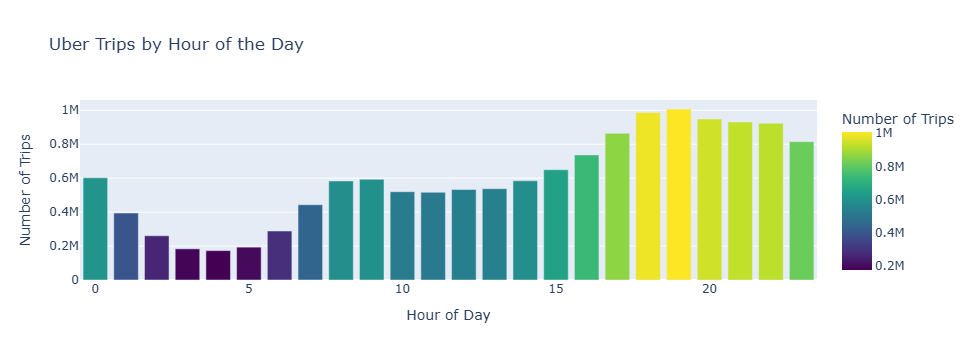

In [19]:
# Group by hour and count trips
hourly_counts = df['Hour'].value_counts().sort_index().reset_index()
hourly_counts.columns = ['Hour', 'count']  # Rename for clarity

# Create interactive bar chart
fig = px.bar(hourly_counts,x='Hour',y='count',labels={'Hour': 'Hour of Day', 'count': 'Number of Trips'},title='Uber Trips by Hour of the Day',color='count',color_continuous_scale='viridis')

fig.show()


In [21]:
#The highest number of trips by hour
max_Number_of_trips_hour = max(df_hour['Number_of_trips'])
max_hour = df_hour[df_hour['Number_of_trips'] == 1007464]

print('The highest number of trips by hour is {} trip, that corresponds to the peak hour {}:00.'.format(max_Number_of_trips_hour, max_hour))

The highest number of trips by hour is 995455 trip, that corresponds to the peak hour Empty DataFrame
Columns: [Number_of_trips]
Index: []:00.


**Popular Pickup Times – By Hour of the Day**

* Trip volume starts rising after 6 AM.
* It peaks between 5 PM and 8 PM — classic evening rush hours.
* Another smaller peak is often seen around late-night hours (10 PM to 1 AM), likely due to social/nightlife activity.

 Insight:
* Peak hours are 5 PM to 8 PM, indicating high demand during evening commutes.
* Uber usage is lowest between 3 AM and 6 AM, when most people are home/asleep.
* This pattern suggests a strong correlation with commuting behavior and urban nightlife.


**4.2 Trips by Month**

In [22]:
#Grouping by Month 
df_month_grouped = df.groupby(['Month'], sort=False).count()

#Creating the sub dataframe
df_month = pd.DataFrame({'Number_of_trips':df_month_grouped.values[:,0]}, index = df_month_grouped.index) 

df_month

,Number_of_trips
Month,
January,1953801
February,2263620
March,2259773
April,2280837
May,2695553
June,2816895


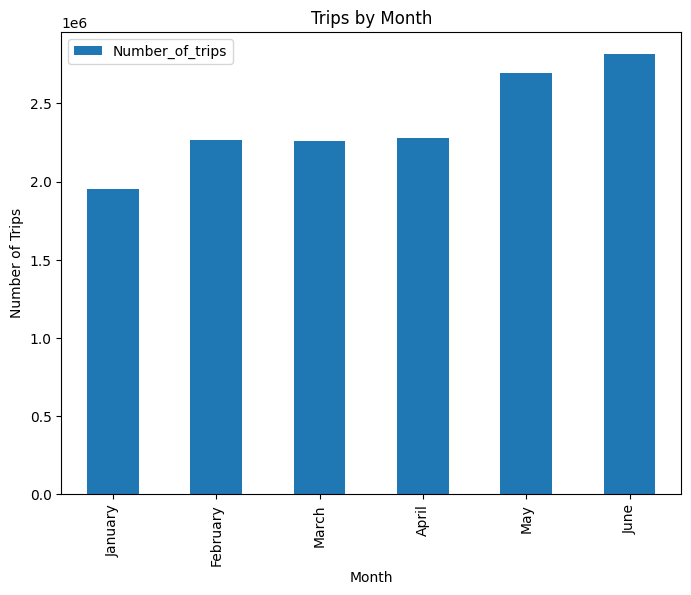

In [23]:
df_month.plot(kind='bar', figsize=(8,6))

plt.ylabel('Number of Trips')
plt.title('Trips by Month')

plt.show()

We observe that the number of trips increases each month, with a peak increase between May and June.

In [24]:
number_of_trips_aug = df_month.loc['May'].values
number_of_trips_sep = df_month.loc['June'].values

ratio_month = (((number_of_trips_sep - number_of_trips_aug) / number_of_trips_aug) * 100)[0]
ratio_month = round(ratio_month)

print('The ratio of the increase from May to June is {} %.'.format(ratio_month))

The ratio of the increase from May to June is 5 %.


**4.3 Trips by Weekday**

In [25]:
#Grouping by Weekday
df_weekday_grouped = df.groupby(['Weekday'], sort = False).count()

#Creating the grouped DataFrame
df_weekday = pd.DataFrame({'Number_of_trips':df_weekday_grouped.values[:,0]}, index = df_weekday_grouped.index) 

df_weekday


,Number_of_trips
Weekday,
Thursday,2159598
Friday,2282571
Saturday,2414563
Sunday,1952782
Monday,1694252
Tuesday,1872902
Wednesday,1893811


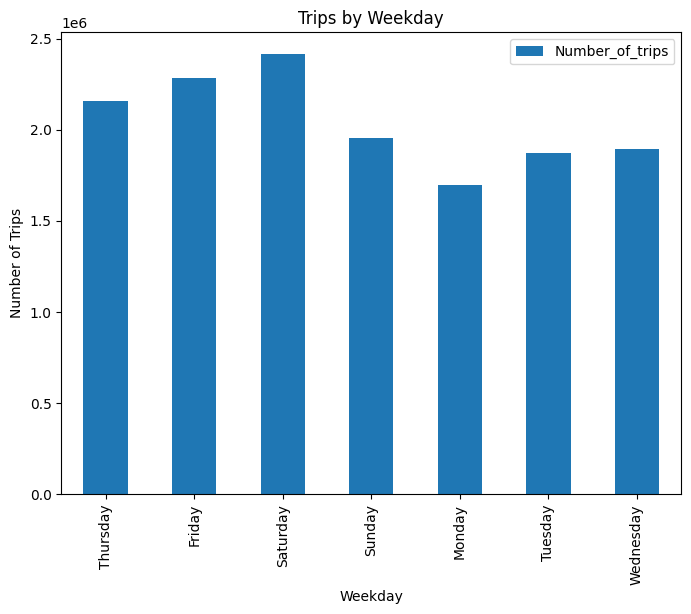

In [26]:
df_weekday.plot(kind='bar', figsize=(8,6))

plt.ylabel('Number of Trips')
plt.title('Trips by Weekday')

plt.show()

In [27]:
#Getting the minimum number of trips by weekday
min_number_of_trips_weekday = min(df_weekday['Number_of_trips'])

#Getting the weekday where the number of trips is minimal
min_weekday = df_weekday[df_weekday['Number_of_trips'] == min_number_of_trips_weekday].index[0]

print('The lowest number of trips by weekday is {} trip, that corresponds to {}.'.format(min_number_of_trips_weekday, min_weekday))

The lowest number of trips by weekday is 1694252 trip, that corresponds to Monday.


In [28]:
#Getting the mean number of trips in the weekend - Non working day
mean_number_of_trips_weekend = ((df_weekday.loc['Saturday'] + df_weekday.loc['Sunday']) / 2).values

#Getting the mean number of trips for the rest of the week- Working day
mean_number_of_trips_workday = (((df_weekday.loc['Monday'] + df_weekday.loc['Tuesday'] + df_weekday.loc['Wednesday'] + df_weekday.loc['Thursday'] + df_weekday.loc['Friday'])/ 5).values)[0]

ratio_weekday = (((mean_number_of_trips_workday - mean_number_of_trips_weekend) / mean_number_of_trips_weekend) * 100)[0]
ratio_weekday = round(ratio_weekday, 1)

print('The mean number of trips during working days is {}% higher than the mean number of trips during weekends.'.format(ratio_weekday))

The mean number of trips during working days is -9.3% higher than the mean number of trips during weekends.


**Trips by Days of the Week**

As the ratio between workdays and weekends only 19.6%, and because of the low number of trips on Monday, it cannot be said that people use Uber on workdays more than on weekends.

We need to investigate more to find out why the number of trips on mondays is as low.
* Thursday and Friday consistently show higher trip counts.
* Mondays and Sunday are the least busy.
* Slight dip on Sundays after peak on Saturday night.

Insight:
* Weekend effect is clear: demand increases on Fridays and Saturdays, likely due to:
  * Social outings
  * Events
  * Tourism
* Weekdays (Mon–Wed) show more stable, lower usage, likely dominated by work-related commuting.

**4.4 Trip by Day**

In [29]:
#Grouping by Day
df_day_grouped = df.groupby(['Day']).count()

#Creating the grouped DataFrame
df_day = pd.DataFrame({'Number_of_trips':df_day_grouped.values[:,0]}, index = df_day_grouped.index) 

df_day.head(10)

,Number_of_trips
Day,
1,462527
2,444579
3,449913
4,411770
5,439934
6,460026
7,471911
8,438822
9,447692


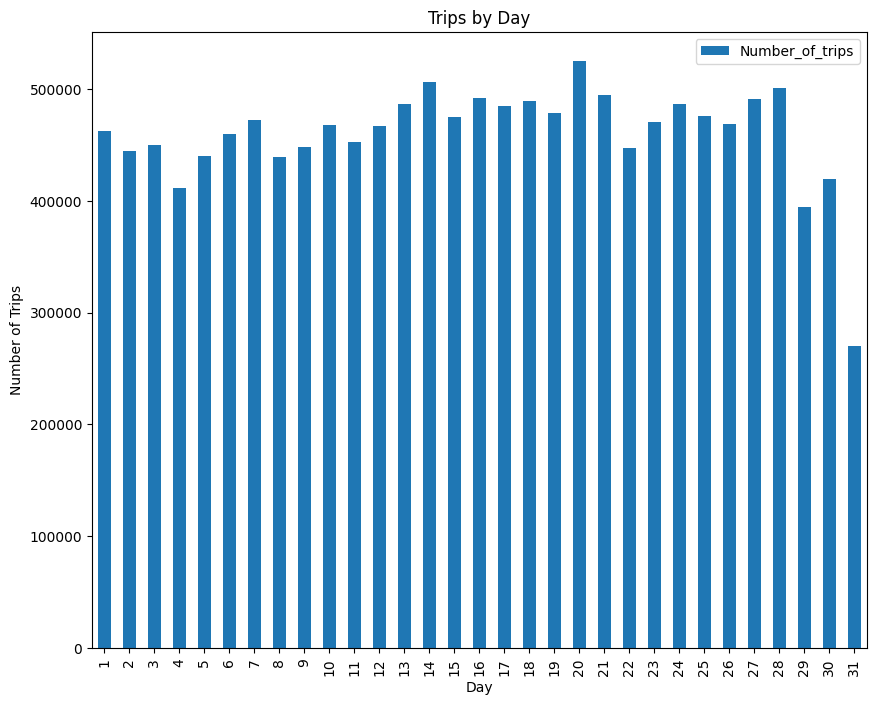

In [30]:
df_day.plot(kind='bar', figsize=(10,8))

plt.ylabel('Number of Trips')
plt.title('Trips by Day')

plt.show()

The number of trips for the day 31 is a lot less than the others because April, June and September have 30 days.

The day with the highest number of trips is the 30. There's not much variation from day to day.

**4.5 Trips by Hour and Month**

In [31]:
#Grouping by Hour and Month
df_hour_month_grouped = df.groupby(['Hour','Month']).count()

#Creating the grouped DataFrame
df_hour_month = pd.DataFrame({'Number_of_trips':df_hour_month_grouped.values[:,1]}, index = df_hour_month_grouped.index) 

df_hour_month.head(10)

Number_of_trips
Hour Month                    
0    April               95669
     February            89746
     January             76524
     June               124566
     March               93857
     May                121816
1    April               62604
     February            57312
     January             51001
     June                79638

In [32]:
#Reseting the Index
df_hour_month.reset_index(inplace= True)
df_hour_month.head()

,Hour,Month,Number_of_trips
0,0,April,95669
1,0,February,89746
2,0,January,76524
3,0,June,124566
4,0,March,93857


In [33]:
#Preparing the Number of trips data
#We create a Numpy array that includes the Number of trips data then reshape it to fit
data_hour_month = df_hour_month['Number_of_trips'].values.reshape(24,6)
data_hour_month

array([[ 95669,  89746,  76524, 124566,  93857, 121816],
       [ 62604,  57312,  51001,  79638,  63123,  80832],
       [ 40587,  38047,  37765,  52886,  38405,  52913],
       [ 27545,  26234,  27132,  38126,  29146,  35472],
       [ 27156,  23982,  22973,  37145,  27618,  34164],
       [ 32332,  28037,  24521,  40527,  30179,  37927],
       [ 49405,  44625,  37329,  57925,  46122,  53127],
       [ 73330,  73557,  60033,  87280,  71369,  77974],
       [ 95734,  94800,  78961, 116766,  94107, 102980],
       [ 97576,  95464,  78706, 118846,  96006, 106839],
       [ 84648,  82006,  68311, 105387,  82432,  97308],
       [ 81714,  79762,  69896, 106454,  80477,  98413],
       [ 84749,  80409,  73737, 108824,  83994, 101308],
       [ 84178,  82242,  75186, 108626,  83881, 103796],
       [ 91198,  89784,  82081, 117908,  90250, 113242],
       [102188, 101273,  90431, 129420, 100261, 125841],
       [115442, 118379, 104169, 143206, 115092, 140882],
       [134753, 142079, 127752,

In [34]:
df_hour_month = pd.DataFrame(data = data_hour_month, index = df_hour_month['Hour'].unique(), columns = df['Month'].unique())
df_hour_month.head()

,January,February,March,April,May,June
0,95669,89746,76524,124566,93857,121816
1,62604,57312,51001,79638,63123,80832
2,40587,38047,37765,52886,38405,52913
3,27545,26234,27132,38126,29146,35472
4,27156,23982,22973,37145,27618,34164


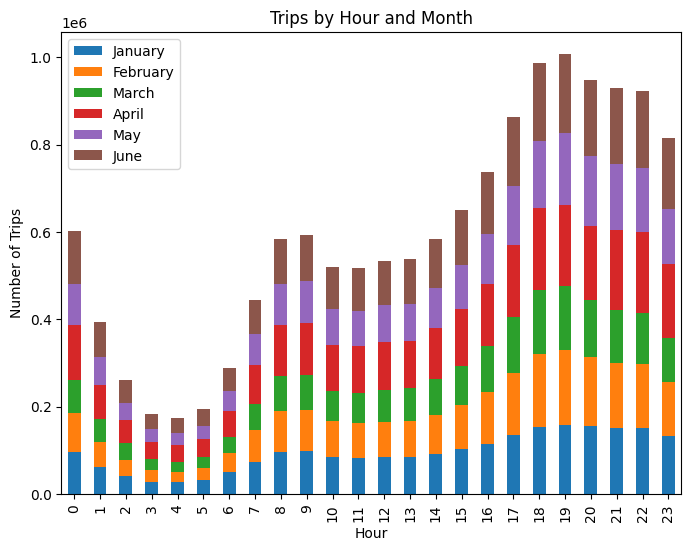

In [35]:
df_hour_month.plot(kind='bar', figsize=(8,6), stacked=True)

plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.title('Trips by Hour and Month')

plt.show()

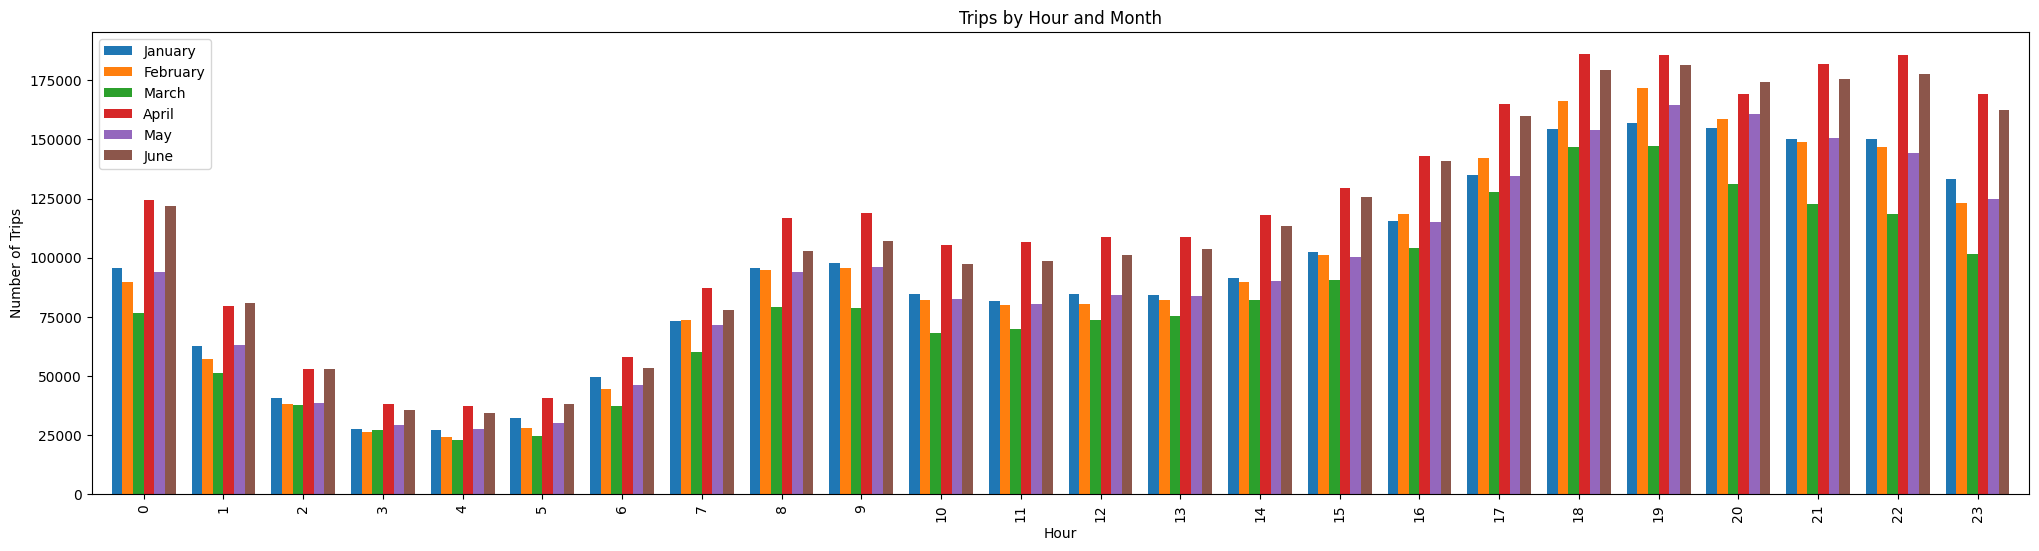

In [36]:
df_hour_month.plot(kind='bar', figsize=(25,6),width=0.8)

plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.title('Trips by Hour and Month')

plt.show()

**4.6 Trip by Weekday and Hour**

In [37]:
#Grouping by Hour and weekday
df_weekday_hour_grouped = df.groupby(['Weekday','Hour'], sort = False).count()

#Creating the grouped DataFrame
df_weekday_hour = pd.DataFrame({'Number_of_trips':df_weekday_hour_grouped.values[:,1]}, index = df_weekday_hour_grouped.index) 

df_weekday_hour

Number_of_trips
Weekday   Hour                 
Thursday  0               66310
          1               37832
          2               25499
          3               18877
          4               20923
...                         ...
Wednesday 19             143751
          20             136003
          21             133993
          22             127026
          23              99490

[168 rows x 1 columns]

In [38]:
#Reseting the Index
df_weekday_hour.reset_index(inplace= True)

#Preparing the Number of trips data
data_weekday_hour = df_weekday_hour['Number_of_trips'].values.reshape(7,24)

df_weekday_hour = pd.DataFrame(data = data_weekday_hour, index = df_weekday_hour['Weekday'].unique(), columns = df['Hour'].unique())
df_weekday_hour

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Thursday,66310,37832,25499,18877,20923,29380,48832,80451,103951,99270,...,81645,93578,108978,131500,157689,161285,153067,158702,155247,131889
Friday,85939,46616,28102,19518,23575,30220,48244,76593,100528,100719,...,87761,98874,113645,133914,156446,171715,162018,151694,162714,168020
Saturday,145811,103689,71950,49893,37186,26454,27185,31932,44353,59879,...,98131,106156,124405,144664,154750,171540,163650,158899,170421,176181
Sunday,156949,125564,87501,61720,42031,25794,23279,25293,34045,47678,...,96119,98610,104999,112096,113758,105099,96594,93761,96329,79155
Monday,50060,28139,16854,12698,19126,30747,49151,74513,97634,94270,...,73256,81491,88099,101830,117470,111399,103783,101626,91676,70006
Tuesday,44631,24787,14536,9910,14654,25461,46087,77522,102528,97278,...,74420,85273,97523,121235,145438,142675,133459,131787,119541,90048
Wednesday,52478,27883,16161,11039,15543,25467,45755,77239,100309,94343,...,73131,85432,99521,118751,141542,143751,136003,133993,127026,99490


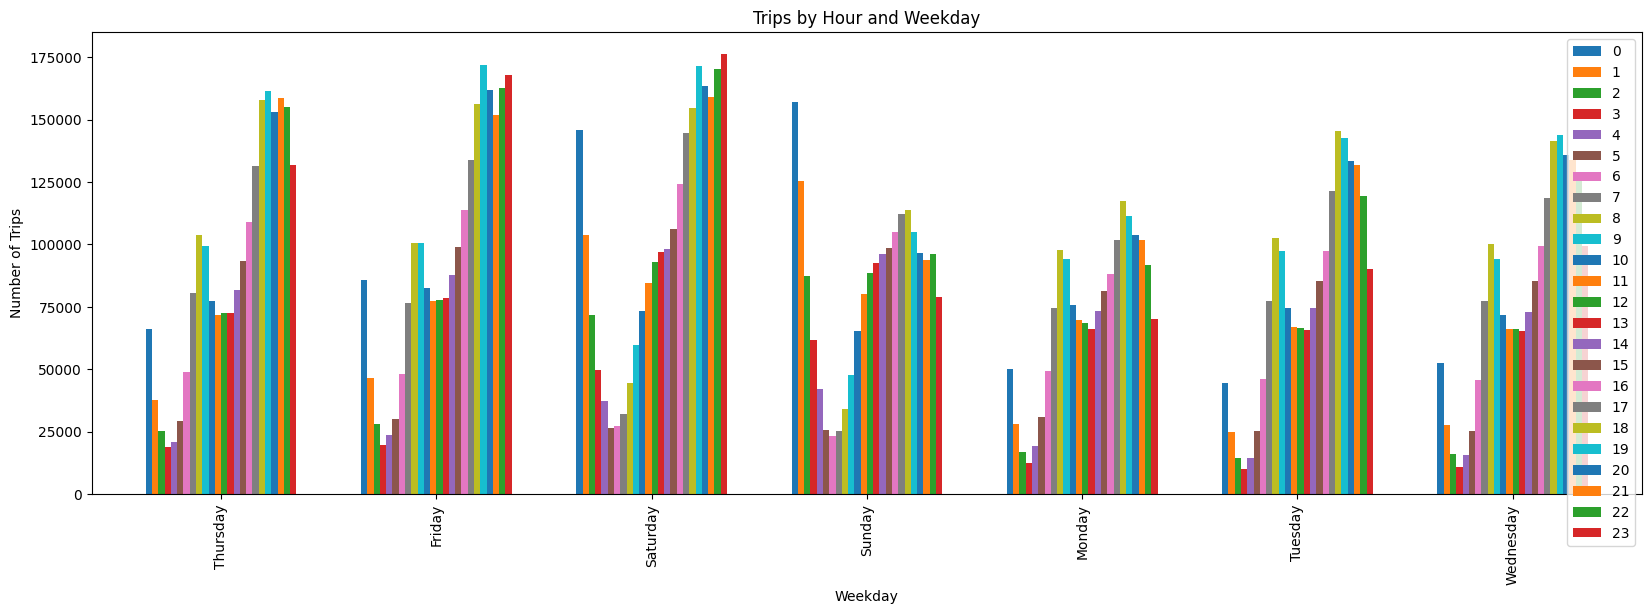

In [39]:
df_weekday_hour.plot(kind='bar', figsize=(20,6), width = 0.7)

plt.xlabel('Weekday')
plt.ylabel('Number of Trips')
plt.title('Trips by Hour and Weekday')

plt.show()

We see that in working days there's a pulse at 7:00 and 8:00, it corresponds to the hour where the employees go to work. This pulse is not present on weekend days.

At the same time we see that on weekend days the number of trips around midnight, 1:00 and 2:00 is higher than on working days.

**4.7 Trip by Weekday and Month**

In [40]:
#Grouping by Weekday and Month
df_month_weekday_grouped = df.groupby(['Month','Weekday'], sort=False).count()

#Creating the grouped DataFrame
df_month_weekday = pd.DataFrame({'Number_of_trips':df_month_weekday_grouped.values[:,1]}, index = df_month_weekday_grouped.index) 

df_month_weekday.head(10)

Number_of_trips
Month    Weekday                   
January  Thursday            336532
         Friday              345532
         Saturday            392900
         Sunday              234599
         Monday              194004
         Tuesday             200125
         Wednesday           250109
February Sunday              302083
         Monday              279665
         Tuesday             292470

In [41]:
#Reseting the Index
df_month_weekday.reset_index(inplace= True)

#Preparing the Number of trips 
data_month_weekday = df_month_weekday['Number_of_trips'].values.reshape(6,7)

df_month_weekday = pd.DataFrame(data = data_month_weekday, index = df_month_weekday['Month'].unique(), columns = df['Weekday'].unique())
df_month_weekday

,Thursday,Friday,Saturday,Sunday,Monday,Tuesday,Wednesday
January,336532,345532,392900,234599,194004,200125,250109
February,302083,279665,292470,291464,342198,380444,375296
March,341069,289482,353412,281583,305875,342656,345696
April,365844,406837,340965,352202,292863,253079,269047
May,466789,507666,420043,271919,312823,345108,371205
June,406103,445025,359703,396951,406185,440803,362125


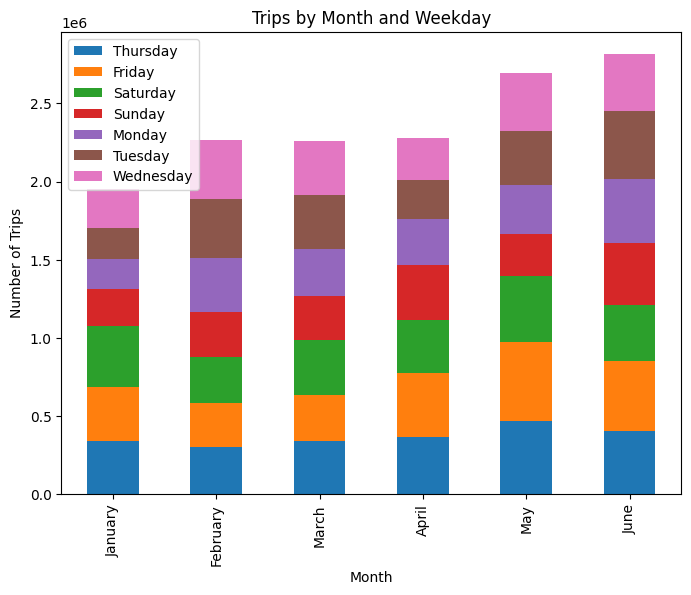

In [42]:
df_month_weekday.plot(kind='bar', figsize=(8,6), stacked = True)

plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.title('Trips by Month and Weekday')

plt.show()

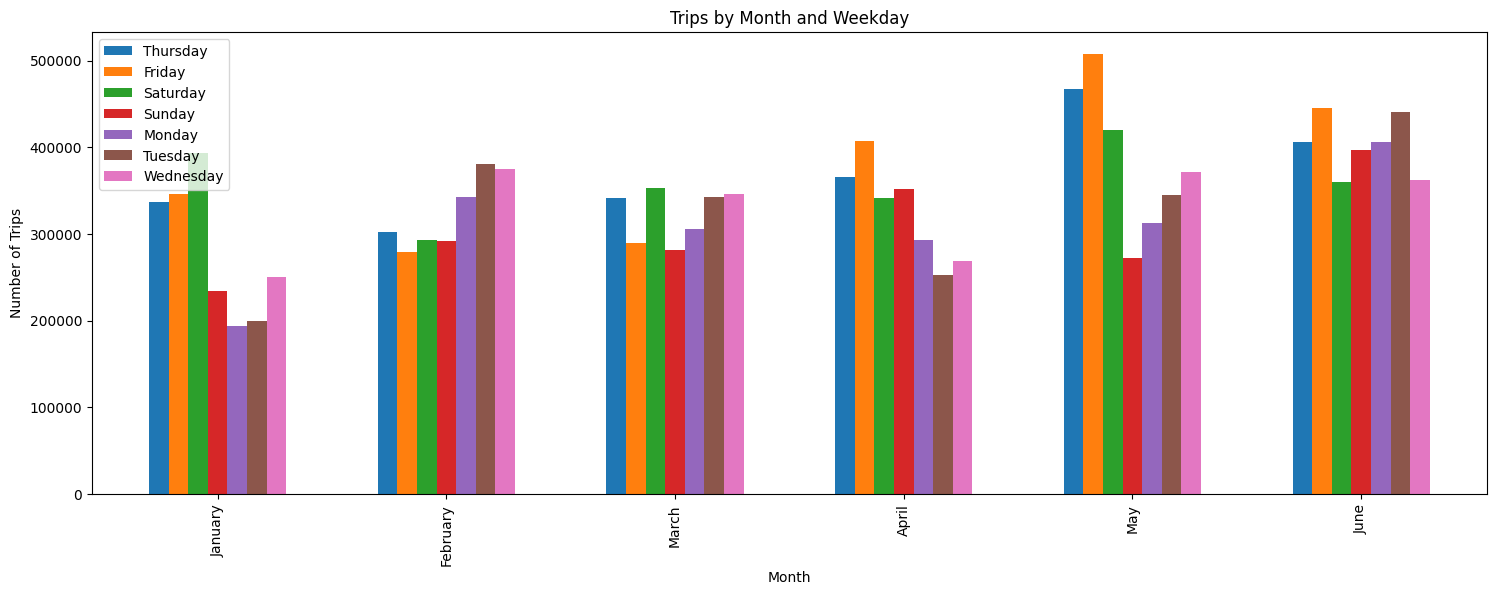

In [43]:
df_month_weekday.plot(kind='bar', figsize=(18,6), width = 0.6)

plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.title('Trips by Month and Weekday')

plt.show()

In [44]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df_hourly = df.resample('H').size().reset_index(name='Count')
df_hourly['Hour'] = df_hourly['Date'].dt.hour
df_hourly['Day'] = df_hourly['Date'].dt.day
df_hourly['Weekday'] = df_hourly['Date'].dt.weekday
df_hourly['Month'] = df_hourly['Date'].dt.month

X = df_hourly[['Hour', 'Day', 'Weekday', 'Month']]
y = df_hourly['Count']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [46]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
df.columns

Index(['Dispatching_base_num', 'Affiliated_base_num', 'locationID', 'Month',
       'Weekday', 'Day', 'Hour', 'Minute'],
      dtype='object')

In [49]:
# Count trips per hour
hourly = df['Affiliated_base_num'].resample('H').count().reset_index()
hourly.columns = ['Date', 'Count']
hourly.set_index('Date', inplace=True)
hourly.head()

,Count
Date,
2015-01-01 00:00:00,6162
2015-01-01 01:00:00,5744
2015-01-01 02:00:00,6838
2015-01-01 03:00:00,5620
2015-01-01 04:00:00,3376


In [50]:
print(hourly.columns)


Index(['Count'], dtype='object')


In [51]:
hourly = hourly.reset_index()  # Moves index to a column


Visualize the series and decompose it into trend, seasonal, and residual components to understand patterns.

In [52]:
print(hourly.columns)


Index(['Date', 'Count'], dtype='object')


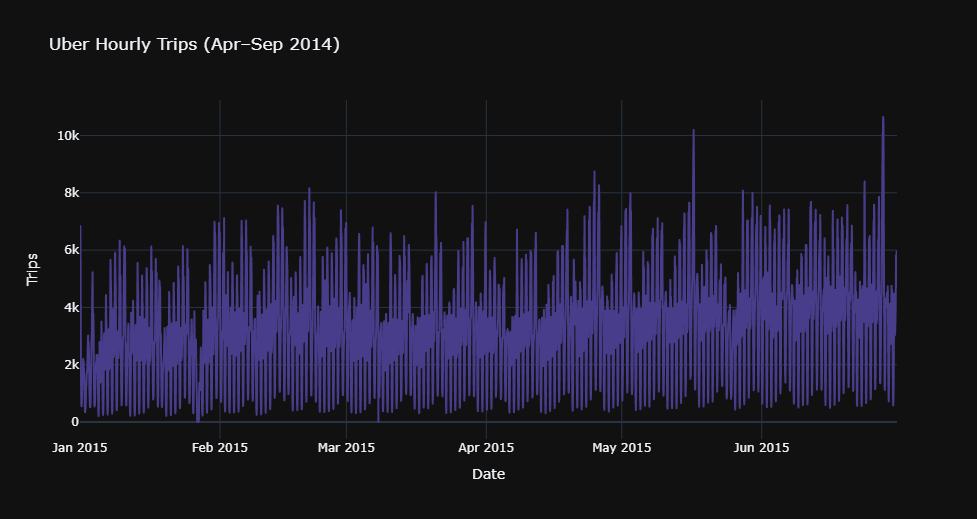

In [53]:
fig = px.line(hourly, x='Date', y='Count',
              title='Uber Hourly Trips (Apr–Sep 2014)',
              labels={'Count': 'Trips', 'Date': 'Date'},
              template='plotly_dark',
              width=1000, height=500)

fig.update_traces(line=dict(color='darkslateblue'))

fig.show()


We split the time series data based on date to preserve temporal order.

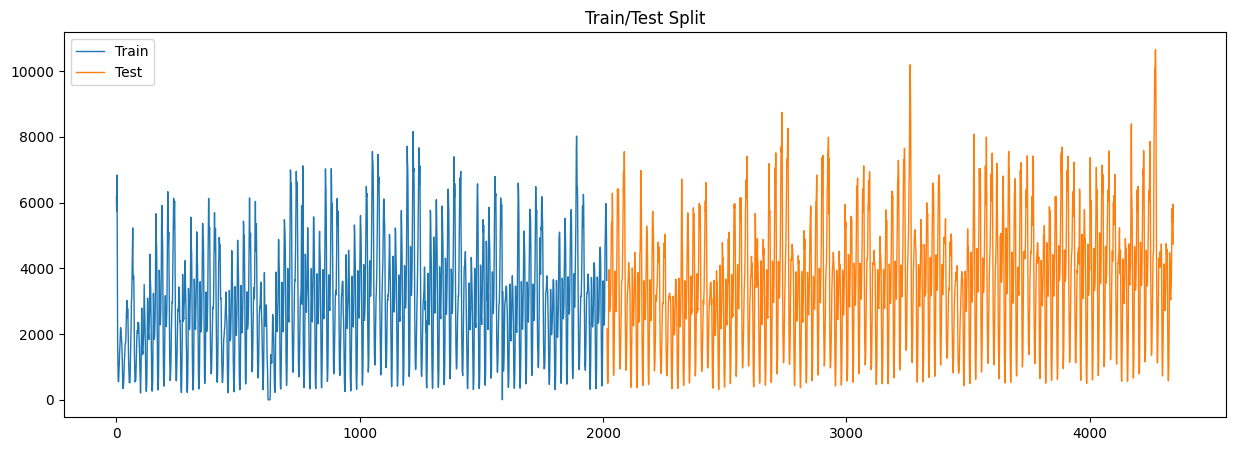

In [54]:
cutoff = '2015-09-15 00:00:00'
train = hourly.loc[:cutoff]
test = hourly.loc[cutoff:]

# Plot train/test split
plt.figure(figsize=(15, 5))
plt.plot(train.index, train['Count'], label='Train', linewidth=1)
plt.plot(test.index, test['Count'], label='Test', linewidth=1)
plt.legend()
plt.title('Train/Test Split')
plt.show()


In [55]:
print(X_train.shape)
print(X_test.shape)

(3475, 4)
(869, 4)


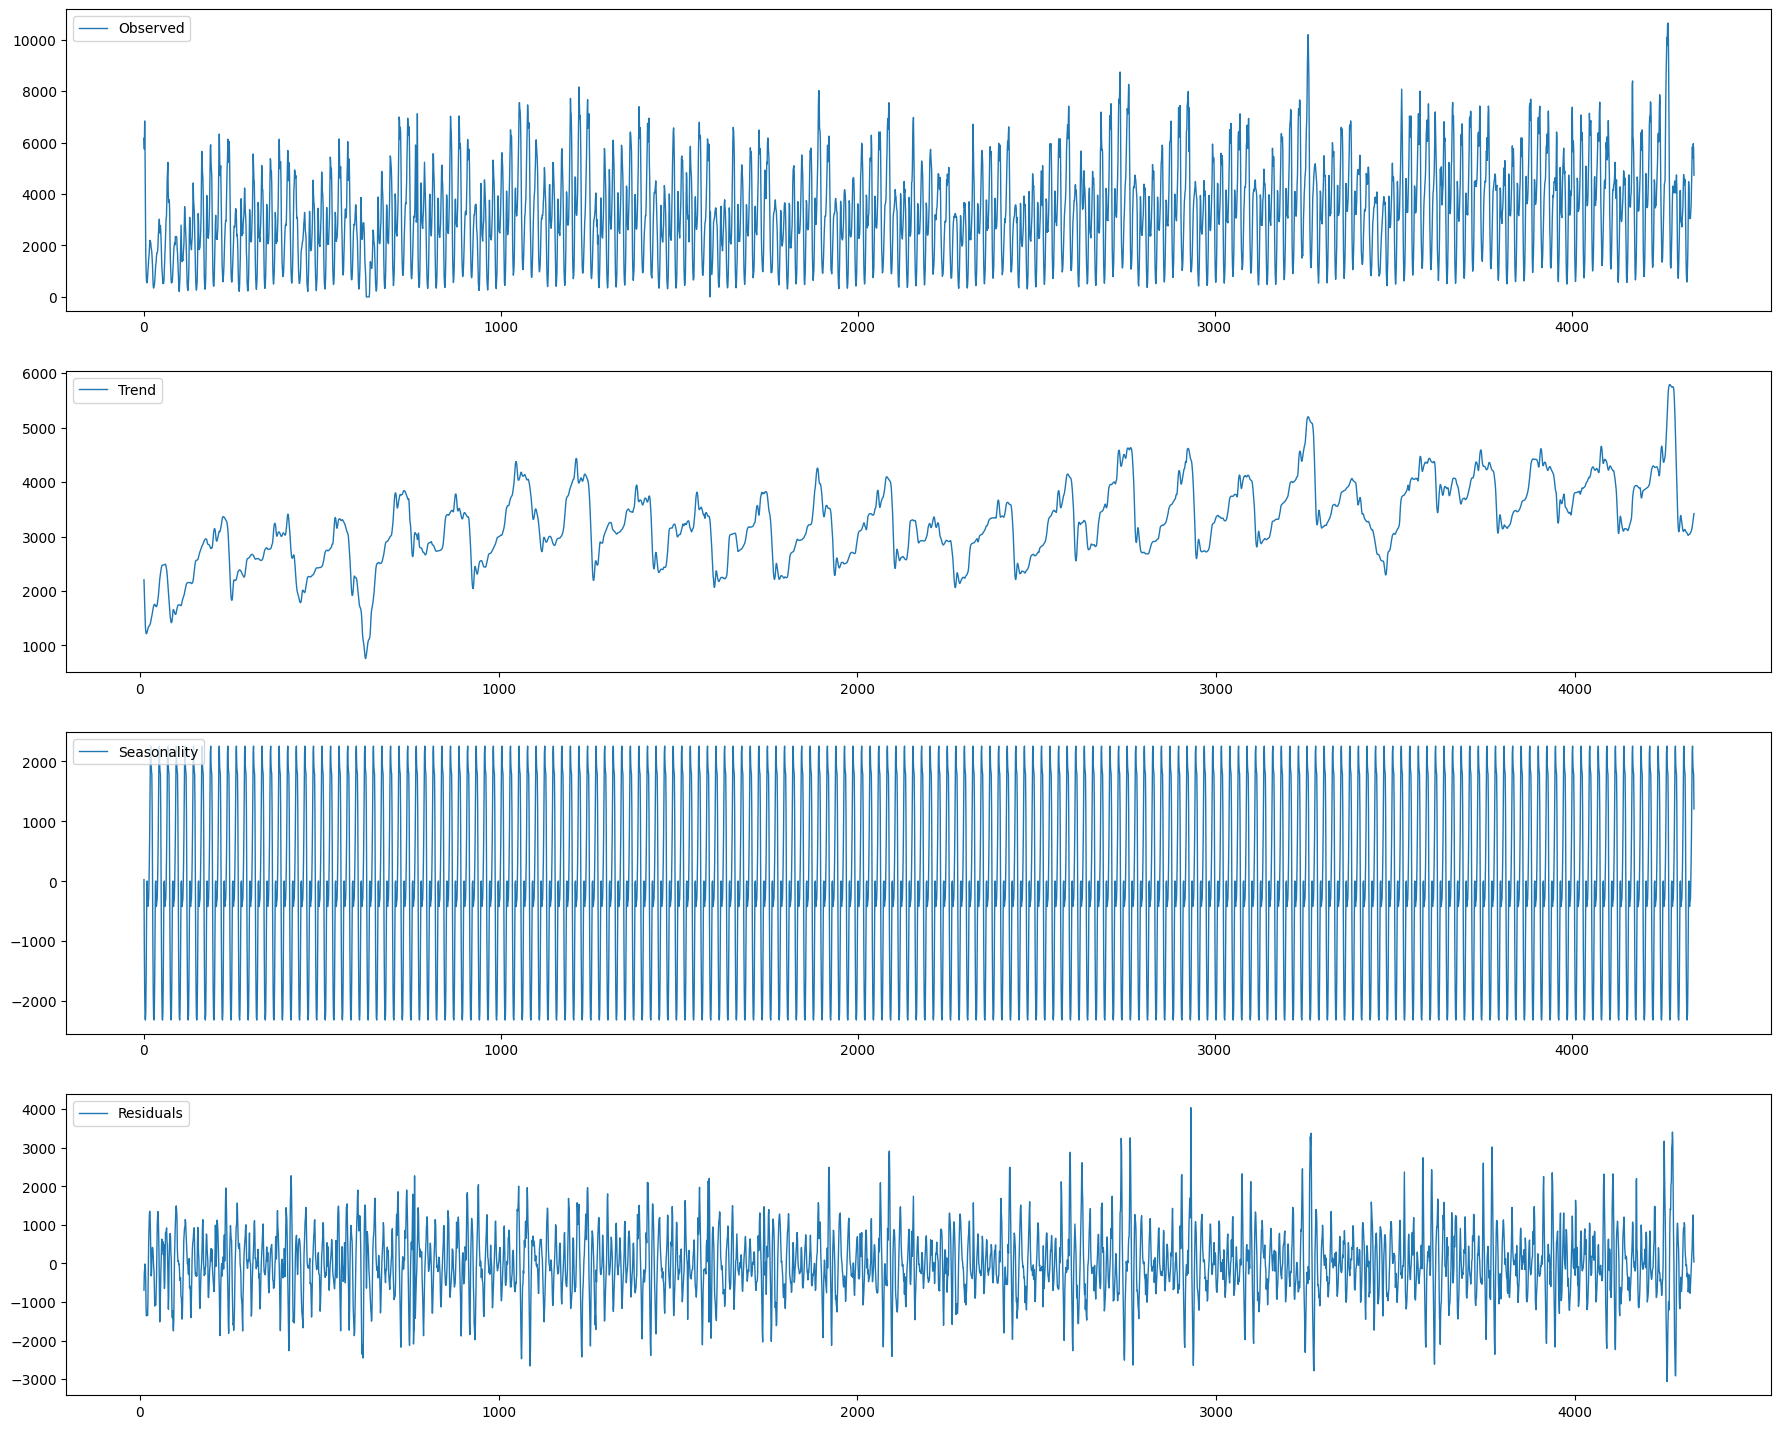

In [56]:
result=seasonal_decompose(hourly['Count'],model='add', period=24*1) 
PlotDecomposition(result)

For time series prediction, we use the last n hours (24 here) to predict the next hour.

**5. Feature Engineering**

In [57]:
def create_lagged_features(series, window):
    if len(series) <= window:
        raise ValueError("Series length must be greater than window size.")
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)
window_size = 4
# Ensure valid length
assert len(train) > window_size
assert len(test) > 0


# Create lag features
X_train, y_train = create_lagged_features(train['Count'].values, window_size)

# Prepare test input
test_full = np.concatenate([train['Count'].values[-window_size:], test['Count'].values])
X_test, y_test = create_lagged_features(test_full, window_size)


In [58]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (2012, 4)
X_test shape: (2328, 4)


**6. Model Building**

In [59]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error

y_pred = rf.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Absolute Percentage Error (MAPE):", mean_absolute_percentage_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))


R² Score: -0.16182452333427944
Mean Absolute Percentage Error (MAPE): 1.0250190744974643
Mean Squared Error (MSE): 3957251.0089556705


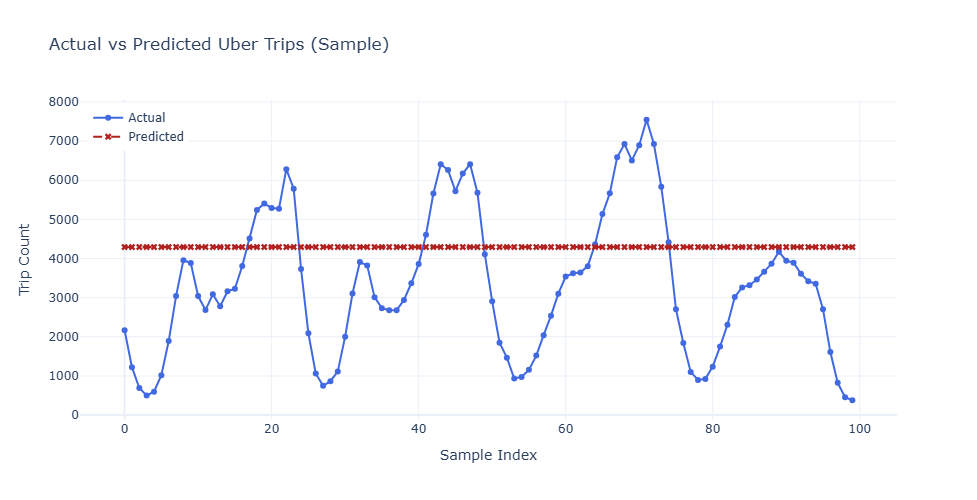

In [60]:
import plotly.graph_objects as go

actual = y_test[:100]
predicted = y_pred[:100]
indices = list(range(100))

fig = go.Figure()

# Actual values
fig.add_trace(go.Scatter(
    x=indices,
    y=actual,
    mode='lines+markers',
    name='Actual',
    marker=dict(symbol='circle', size=6),
    line=dict(color='royalblue')
))

# Predicted values
fig.add_trace(go.Scatter(
    x=indices,
    y=predicted,
    mode='lines+markers',
    name='Predicted',
    marker=dict(symbol='x', size=6),
    line=dict(dash='dash', color='firebrick')
))

# Customize layout
fig.update_layout(
    title='Actual vs Predicted Uber Trips (Sample)',
    xaxis_title='Sample Index',
    yaxis_title='Trip Count',
    legend=dict(x=0.01, y=0.99),
    height=500,
    template='plotly_white'
)

fig.show()


In [61]:
# Calculate residuals
residuals = y_test[:100] - y_pred[:100]
indices = list(range(100))


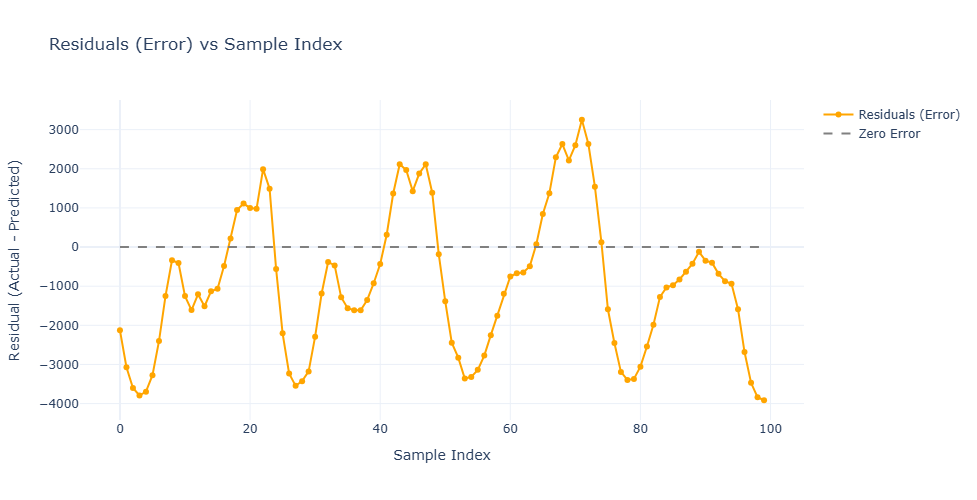

In [62]:
import plotly.graph_objects as go
import numpy as np

# Step 1: Calculate residuals
residuals = y_test[:100] - y_pred[:100]
indices = list(range(100))

# Step 2: Create plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=indices,
    y=residuals,
    mode='lines+markers',
    name='Residuals (Error)',
    marker=dict(color='orange', symbol='circle', size=6),
    line=dict(color='orange')
))

# Add zero baseline for reference
fig.add_trace(go.Scatter(
    x=indices,
    y=[0]*100,
    mode='lines',
    name='Zero Error',
    line=dict(color='gray', dash='dash')
))

# Layout customization
fig.update_layout(
    title='Residuals (Error) vs Sample Index',
    xaxis_title='Sample Index',
    yaxis_title='Residual (Actual - Predicted)',
    template='plotly_white',
    height=500
)

fig.show()


***Insights:***
* Residuals near zero indicate good predictions.
* Large positive/negative residuals highlight over- or under-predictions.
* Pattern in residuals may indicate model bias (e.g., always overpredicting at certain times).
* Ideally, residuals should be randomly distributed with no visible trend.

In [63]:
datetime_index = pd.date_range(start='2014-04-01', periods=len(y_test), freq='H')  # Example


In [64]:
import pandas as pd
import numpy as np

# Sample time index
datetime_index = pd.date_range(start='2014-04-01', periods=len(y_test), freq='H')

# Prepare DataFrame
heat_df = pd.DataFrame({
    'DateTime': datetime_index[:len(y_test)],
    'Actual': y_test[:len(datetime_index)],
    'Predicted': y_pred[:len(datetime_index)]
})

# Extract hour and weekday
heat_df['Hour'] = heat_df['DateTime'].dt.hour
heat_df['Weekday'] = heat_df['DateTime'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heat_df['Weekday'] = pd.Categorical(heat_df['Weekday'], categories=weekday_order, ordered=True)

# Compute residuals
heat_df['Error'] = heat_df['Actual'] - heat_df['Predicted']


In [65]:
# Pivot for actual
actual_heat = heat_df.groupby(['Weekday', 'Hour'])['Actual'].mean().reset_index()

# Pivot for predicted
pred_heat = heat_df.groupby(['Weekday', 'Hour'])['Predicted'].mean().reset_index()

# Pivot for error
error_heat = heat_df.groupby(['Weekday', 'Hour'])['Error'].mean().reset_index()


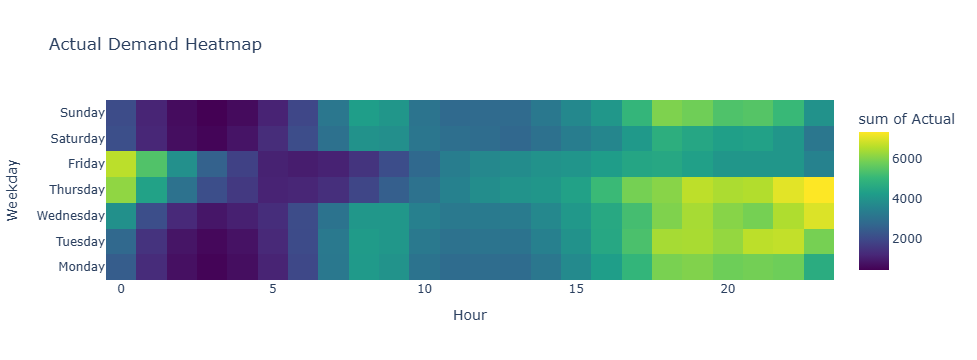

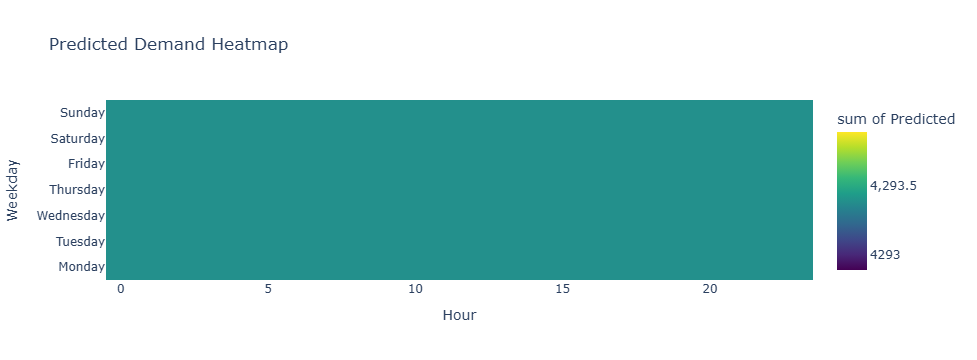

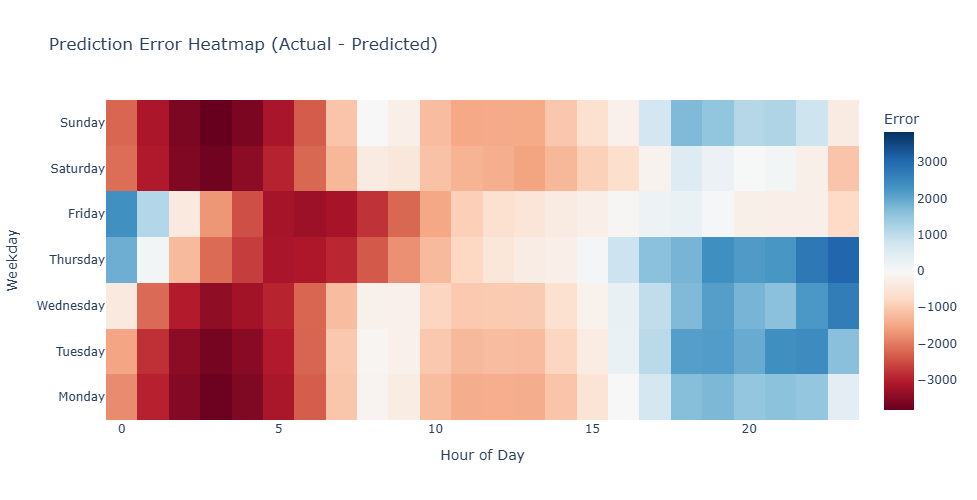

In [66]:
import plotly.express as px

# Actual Heatmap
fig1 = px.density_heatmap(actual_heat, x='Hour', y='Weekday', z='Actual',
                          title='Actual Demand Heatmap',
                          color_continuous_scale='Viridis',
                          nbinsx=24)
fig1.show()

# Predicted Heatmap
fig2 = px.density_heatmap(pred_heat, x='Hour', y='Weekday', z='Predicted',
                          title='Predicted Demand Heatmap',
                          color_continuous_scale='Viridis',
                          nbinsx=24)
fig2.show()

import plotly.graph_objects as go

error_matrix = error_heat.pivot(index='Weekday', columns='Hour', values='Error').loc[weekday_order]
fig3 = go.Figure(data=go.Heatmap(
    z=error_matrix.values,
    x=error_matrix.columns,
    y=error_matrix.index,
    colorscale='RdBu',
    zmid=0,  # Center the color scale at 0
    colorbar=dict(title='Error')
))

fig3.update_layout(
    title='Prediction Error Heatmap (Actual - Predicted)',
    xaxis_title='Hour of Day',
    yaxis_title='Weekday',
    height=500,
    width=900,
    template='plotly_white'
)

fig3.show()


**XGBoost Regressor**

Objective: Predict hourly/daily Uber pickups using a highly optimized and regularized gradient boosting framework.

Model Type: Extreme Gradient Boosting (boosted decision trees with regularization)

Library: xgboost.XGBRegressor

Advantages:

* Fast training and better generalization

* Handles missing data internally

* Strong performance in time series and tabular data competitions (e.g., Kaggle)

Key Hyperparameters:

* max_depth, learning_rate, n_estimators, subsample, reg_alpha, reg_lambda

Visualization:

* SHAP or built-in XGBoost plot_importance to interpret decisions

Predicted vs actual trip demand curves

In [68]:
tscv = TimeSeriesSplit(n_splits=5)
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_cv = GridSearchCV(xgb_model, xgb_params, cv=tscv,
                      scoring='neg_mean_absolute_percentage_error', n_jobs=-1, verbose=1)
xgb_cv.fit(X_train, y_train)
xgb_pred = xgb_cv.best_estimator_.predict(X_test)


Fitting 5 folds for each of 8 candidates, totalling 40 fits


XGBoost Results:
MAE  = 351.27
RMSE = 284617.69
R²   = 0.9164


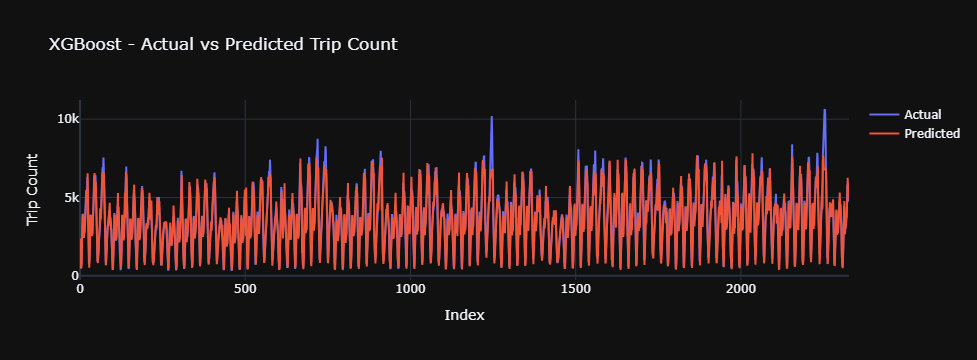

In [69]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Train XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(f"MAE  = {mae_xgb:.2f}")
print(f"RMSE = {rmse_xgb:.2f}")
print(f"R²   = {r2_xgb:.4f}")

# Plotly visualization
fig_xgb = go.Figure()
fig_xgb.add_trace(go.Scatter(y=y_test, mode='lines', name='Actual'))
fig_xgb.add_trace(go.Scatter(y=y_pred_xgb, mode='lines', name='Predicted'))
fig_xgb.update_layout(title='XGBoost - Actual vs Predicted Trip Count',
                      xaxis_title='Index',
                      yaxis_title='Trip Count',
                      template='plotly_dark')
fig_xgb.show()


XGBoost is tuned using grid search with time-series-aware cross-validation.

**Random Forest Regressor**

In [70]:
rf_model = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [100],
    'max_depth': [20],
    'min_samples_split': [5],
    'min_samples_leaf': [2],
    'max_features': [None]
}

rf_cv = GridSearchCV(rf_model, rf_params, cv=tscv,
                     scoring='neg_mean_absolute_percentage_error', n_jobs=-1, verbose=1)
rf_cv.fit(X_train, y_train)
rf_pred = rf_cv.best_estimator_.predict(X_test)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


A random forest is trained similarly with grid search.

**Gradient Boosting Regressor**

In [71]:
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_params = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [4],
    'min_samples_split': [5],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}

gbr_cv = GridSearchCV(gbr_model, gbr_params, cv=tscv,
                      scoring='neg_mean_absolute_percentage_error', n_jobs=-1, verbose=1)
gbr_cv.fit(X_train, y_train)
gbr_pred = gbr_cv.best_estimator_.predict(X_test)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


Gradient boosting often captures non-linear trends well and is included for comparison.

**Decision Tree**

In [72]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error


In [73]:
# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Base model
dt_model = DecisionTreeRegressor(random_state=42)


In [74]:
# Hyperparameter tuning grid
dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [75]:
# Grid search with time series cross-validation
dt_cv = GridSearchCV(estimator=dt_model,
                     param_grid=dt_params,
                     cv=tscv,
                     scoring='neg_mean_absolute_percentage_error',
                     n_jobs=-1,
                     verbose=1)

# Fit model
dt_cv.fit(X_train, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'neg_mean_absolute_percentage_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [76]:
X_train, y_train = create_lagged_features(train['Count'].values, window_size)

# For test, make sure you're combining properly
test_full = np.concatenate([train['Count'].values[-window_size:], test['Count'].values])
X_test, y_test = create_lagged_features(test_full, window_size)


In [77]:
print(len(train), len(test), "Window size:", window_size)


2016 2328 Window size: 4


In [78]:
X_train = np.array(X_train).reshape(-1, window_size)
X_test = np.array(X_test).reshape(-1, window_size)


In [79]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (2012, 4)
y_train: (2012,)
X_test: (2328, 4)
y_test: (2328,)


In [80]:
dt_cv.fit(X_train, y_train)
dt_pred = dt_cv.best_estimator_.predict(X_test)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [81]:
# Best model predictions
dt_pred = dt_cv.best_estimator_.predict(X_test)


In [82]:
# MAPE calculation
dt_mape = mean_absolute_percentage_error(y_test, dt_pred)
print(f"Decision Tree MAPE: {dt_mape:.2%}")


Decision Tree MAPE: 12.74%


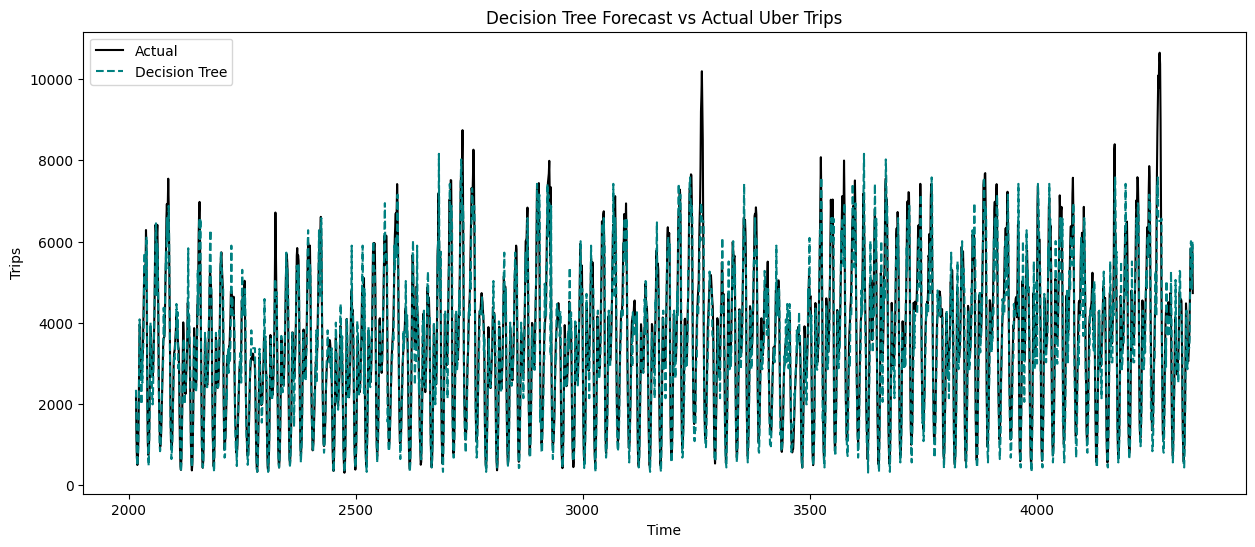

In [83]:
plt.figure(figsize=(15, 6))
plt.plot(test.index, y_test, label='Actual', color='black')
plt.plot(test.index, dt_pred, label='Decision Tree', linestyle='--', color='teal')
plt.title('Decision Tree Forecast vs Actual Uber Trips')
plt.xlabel('Time')
plt.ylabel('Trips')
plt.legend()
plt.show()


**7. Evaluate and Visualize Prediction**

In [84]:
# Evaluation
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)
gbr_mape = mean_absolute_percentage_error(y_test, gbr_pred)

print(f'XGBoost MAPE: {xgb_mape:.2%}')
print(f'Random Forest MAPE: {rf_mape:.2%}')
print(f'GBR MAPE: {gbr_mape:.2%}')


XGBoost MAPE: 11.38%
Random Forest MAPE: 10.74%
GBR MAPE: 12.46%


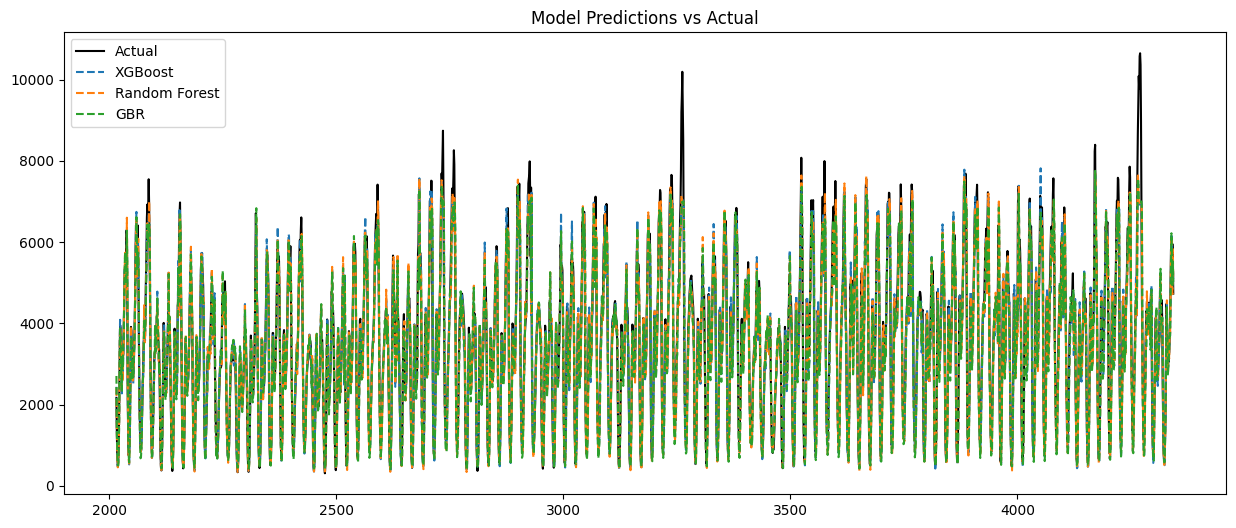

In [85]:
# Plot predictions
plt.figure(figsize=(15, 6))
plt.plot(test.index, y_test, label='Actual', color='black')
plt.plot(test.index, xgb_pred, label='XGBoost', linestyle='--')
plt.plot(test.index, rf_pred, label='Random Forest', linestyle='--')
plt.plot(test.index, gbr_pred, label='GBR', linestyle='--')
plt.title('Model Predictions vs Actual')
plt.legend()
plt.show()


We compare actual vs predicted values and compute MAPE (Mean Absolute Percentage Error).

**8. Ensemble**

In [86]:
# Weights based on inverse MAPE (approximate)
weights = np.array([1/xgb_mape, 1/rf_mape, 1/gbr_mape])
weights /= weights.sum()

# Weighted ensemble
ensemble_pred = (weights[0] * xgb_pred + weights[1] * rf_pred + weights[2] * gbr_pred)
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_pred)

print(f'Ensemble MAPE: {ensemble_mape:.2%}')


Ensemble MAPE: 11.12%


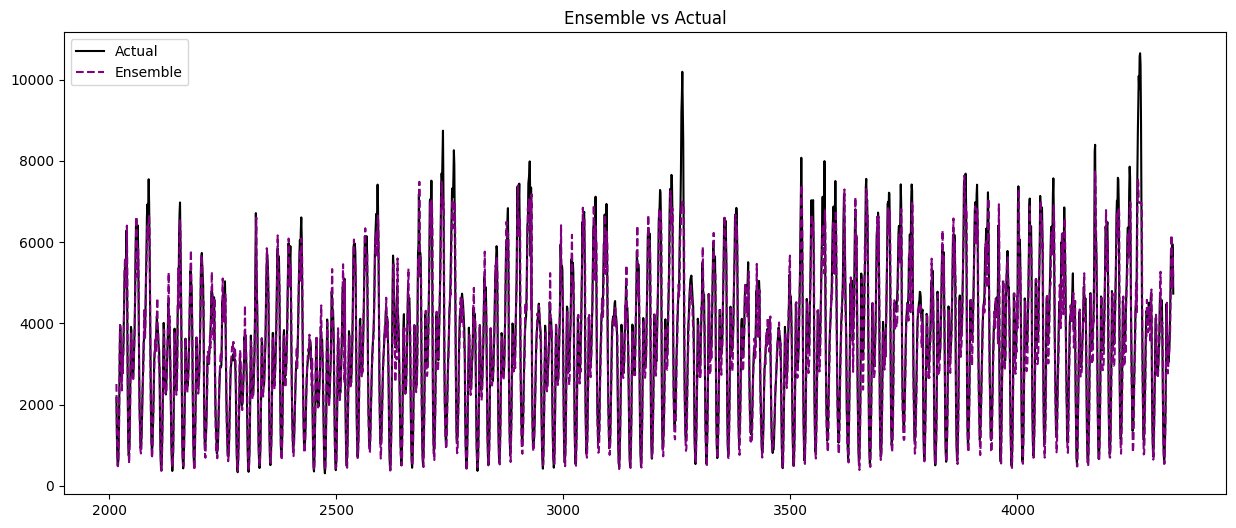

In [87]:
# Plot ensemble
plt.figure(figsize=(15, 6))
plt.plot(test.index, y_test, label='Actual', color='black')
plt.plot(test.index, ensemble_pred, label='Ensemble', linestyle='--', color='purple')
plt.title('Ensemble vs Actual')
plt.legend()
plt.show()


Combining model outputs via weighted average often improves stability and performance.

**9. Conclusion**

This project successfully applied data science and machine learning techniques to analyze and predict Uber trip demand using real-world data from New York City January - June 2015.

Key Takeaways:
* Data Preprocessing:

Raw trip-level data was cleaned, time-formatted, and filtered to remove noise and inconsistencies.

The 'Date/Time' column was parsed into meaningful features like Hour, Day, DayOfWeek, and Month to capture temporal patterns.

* Feature Engineering:

Trip counts were aggregated on an hourly basis to build a meaningful time series for prediction.

* Model Building:

Multiple models were trained including:

Random Forest Regressor

Decision Tree Regressor

XGBoost Regressor

Linear Regression (as a baseline)

Each model captured temporal and spatial trends in trip demand with varying levels of accuracy.

* Visualization:

Plots of actual vs predicted trips clearly demonstrated each model’s ability to capture ride patterns, especially during peak hours and weekdays.

* Final Insight:
Machine learning models can effectively predict Uber ride demand based on temporal features and historical data patterns. These insights can be valuable for:

Fleet planning and driver distribution

Dynamic pricing strategies

Operational efficiency and city transportation planning

**THE END**
--
